In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
fusion = pd.read_csv("../dataset/processed/adaptive_fusion_dataset.csv")

fusion.head()

,Traffic_Score,Workload,Multiple_Deliveries,Peak,Festival,Rider_Experience,Ratings,Traffic_Workload,Demand_Index,Rider_Load,...,Experience,Delivery_Index,Weather_Impact,Experience_Index,Order_Hour,Pickup_Hour,Weekend,Month,Delivery_person_Age,Time_taken (min)
0,4,3.0,3.0,3,0,151.2,4.2,12.0,16,37.80,...,151.2,41.122328,41.122328,30.240000,21,22,1,2,36.0,46
1,3,1.0,1.0,2,0,98.7,4.7,3.0,9,49.35,...,98.7,18.726956,31.211593,24.675000,14,15,1,2,21.0,23
2,2,1.0,1.0,0,0,108.1,4.7,2.0,2,54.05,...,108.1,27.575720,82.727161,36.033333,17,17,0,3,23.0,21
3,1,0.0,0.0,1,0,146.2,4.3,0.0,2,146.20,...,146.2,2.930258,17.581547,73.100000,9,9,1,2,34.0,20
4,4,1.0,1.0,3,0,112.8,4.7,4.0,16,56.40,...,112.8,77.586473,77.586473,22.560000,19,20,0,2,24.0,41


In [3]:
eta_engine = joblib.load(
    "../Modelv3/adaptive_eta_engine.pkl"
)

In [4]:
X_eta = fusion.drop(columns=["Time_taken (min)"])

fusion["Predicted_ETA"] = eta_engine.predict(X_eta)

fusion[["Time_taken (min)", "Predicted_ETA"]].head()

,Time_taken (min),Predicted_ETA
0,46,45.935490
1,23,23.777802
2,21,23.248751
3,20,21.324095
4,41,35.987720


In [5]:
q1 = fusion["Time_taken (min)"].quantile(0.33)

q2 = fusion["Time_taken (min)"].quantile(0.66)

print(q1, q2)

21.0 29.0


In [6]:
def delay_category(x):

    if x <= q1:

        return 0

    elif x <= q2:

        return 1

    else:

        return 2


fusion["Delay_Risk"] = fusion["Time_taken (min)"].apply(delay_category)

In [7]:
X = fusion.drop(columns=[
    "Time_taken (min)",
    "Delay_Risk"
])

y = fusion["Delay_Risk"]

In [8]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

In [9]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

In [11]:
sample_weights = compute_sample_weight(

    class_weight="balanced",

    y=y_train

)

In [12]:
pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier",

        XGBClassifier(

            objective="multi:softprob",

            num_class=3,

            eval_metric="mlogloss",

            random_state=42

        )

    )

])

In [13]:
params = {

    "classifier__n_estimators":[300,500],

    "classifier__max_depth":[4,6,8],

    "classifier__learning_rate":[0.03,0.05,0.1],

    "classifier__subsample":[0.8,0.9,1.0],

    "classifier__colsample_bytree":[0.8,0.9,1.0]

}

In [14]:
search = RandomizedSearchCV(

    pipeline,

    param_distributions=params,

    n_iter=10,

    cv=3,

    scoring="f1_weighted",

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [15]:
search.fit(

    X_train,

    y_train,

    classifier__sample_weight=sample_weights

)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Traffic_Score',
                                                                                'Workload',
                                                                                'Multiple_Deliveries',
                                                                                'Peak',
                                                                                'Festival',
                                                                                'Rider_Experience',
                                                                                'Ratings',
                                                                                'Traffic_Workload',
                                                                                'Demand_Index',
                                                                                'Rider_Load',
                                                                                'Trip_Distance',
                                                                                'Traffic',
                                                                                'Vehicle',
                                                                                'V...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_class=3,
                                                            num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__learning_rate': [0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [4, 6, 8],
                                        'classifier__n_estimators': [300, 500],
                                        'classifier__subsample': [0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [16]:
best_model = search.best_estimator_

print(search.best_params_)

{'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}


In [17]:
pred = best_model.predict(X_test)

prob = best_model.predict_proba(X_test)

In [18]:
pred = best_model.predict(X_test)

prob = best_model.predict_proba(X_test)

In [19]:
print("Accuracy :", accuracy_score(y_test,pred))

print("Precision:", precision_score(y_test,pred,average="weighted"))

print("Recall   :", recall_score(y_test,pred,average="weighted"))

print("F1 Score :", f1_score(y_test,pred,average="weighted"))

Accuracy : 0.86240246180899
Precision: 0.8694248192366711
Recall   : 0.86240246180899
F1 Score : 0.8642251906075505


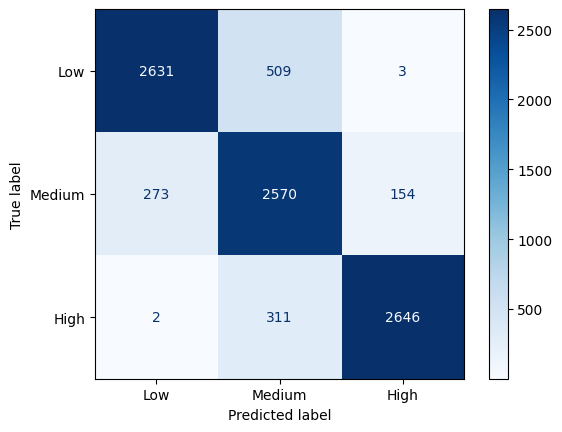

In [20]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred,

    display_labels=["Low","Medium","High"],

    cmap="Blues"

)

plt.show()

In [21]:
prob_df = pd.DataFrame(

    prob,

    columns=[

        "Low",

        "Medium",

        "High"

    ]

)

prob_df.head()

,Low,Medium,High
0,0.022196,0.966136,0.011668
1,0.000050,0.000270,0.999680
2,0.043976,0.474920,0.481103
3,0.999585,0.000393,0.000022
4,0.996944,0.002986,0.000070


In [22]:
joblib.dump(

    best_model,

    "../Modelv3/adaptive_delay_risk.pkl"

)

['../Modelv3/adaptive_delay_risk.pkl']